이 자료는 위키독스 딥 러닝을 이용한 자연어 처리 입문의 자동 미분과 선형 회귀 튜토리얼입니다.  

링크 : https://wikidocs.net/111472

# 1. 자동 미분

In [1]:
import tensorflow as tf

In [2]:
tf.__version__

'2.20.0'

In [3]:
w = tf.Variable(2.)

def f(w):
  y = w**2
  z = 2*y + 5
  return z

In [4]:
with tf.GradientTape() as tape:
  z = f(w)

gradients = tape.gradient(z, [w])
print(gradients)

[<tf.Tensor: shape=(), dtype=float32, numpy=8.0>]


# 2. 자동 미분을 이용한 선형 회귀 구현

In [5]:
# 학습될 가중치 변수를 선언
W = tf.Variable(4.0)
b = tf.Variable(1.0)

In [6]:
@tf.function
def hypothesis(x):
  return W*x + b

In [7]:
x_test = [3.5, 5, 5.5, 6]
print(hypothesis(x_test).numpy())

[15. 21. 23. 25.]


In [8]:
@tf.function
def mse_loss(y_pred, y):
  # 두 개의 차이값을 제곱을 해서 평균을 취한다.
  return tf.reduce_mean(tf.square(y_pred - y))

In [9]:
x = [1, 2, 3, 4, 5, 6, 7, 8, 9] # 공부하는 시간
y = [11, 22, 33, 44, 53, 66, 77, 87, 95] # 각 공부하는 시간에 맵핑되는 성적

In [10]:
optimizer = tf.optimizers.SGD(0.01)

In [11]:
for i in range(301):
  with tf.GradientTape() as tape:
    # 현재 파라미터에 기반한 입력 x에 대한 예측값을 y_pred
    y_pred = hypothesis(x)

    # 평균 제곱 오차를 계산
    cost = mse_loss(y_pred, y)

  # 손실 함수에 대한 파라미터의 미분값 계산
  gradients = tape.gradient(cost, [W, b])

  # 파라미터 업데이트
  optimizer.apply_gradients(zip(gradients, [W, b]))

  if i % 10 == 0:
    print("epoch : {:3} | W의 값 : {:5.4f} | b의 값 : {:5.4} | cost : {:5.6f}".format(i, W.numpy(), b.numpy(), cost))

epoch :   0 | W의 값 : 8.2133 | b의 값 : 1.664 | cost : 1402.555542
epoch :  10 | W의 값 : 10.4971 | b의 값 : 1.977 | cost : 1.351182
epoch :  20 | W의 값 : 10.5047 | b의 값 :  1.93 | cost : 1.328165
epoch :  30 | W의 값 : 10.5119 | b의 값 : 1.884 | cost : 1.306967
epoch :  40 | W의 값 : 10.5188 | b의 값 : 1.841 | cost : 1.287436
epoch :  50 | W의 값 : 10.5254 | b의 값 : 1.799 | cost : 1.269459
epoch :  60 | W의 값 : 10.5318 | b의 값 : 1.759 | cost : 1.252898
epoch :  70 | W의 값 : 10.5379 | b의 값 : 1.721 | cost : 1.237644
epoch :  80 | W의 값 : 10.5438 | b의 값 : 1.684 | cost : 1.223598
epoch :  90 | W의 값 : 10.5494 | b의 값 : 1.648 | cost : 1.210658
epoch : 100 | W의 값 : 10.5548 | b의 값 : 1.614 | cost : 1.198740
epoch : 110 | W의 값 : 10.5600 | b의 값 : 1.582 | cost : 1.187767
epoch : 120 | W의 값 : 10.5650 | b의 값 :  1.55 | cost : 1.177665
epoch : 130 | W의 값 : 10.5697 | b의 값 :  1.52 | cost : 1.168354
epoch : 140 | W의 값 : 10.5743 | b의 값 : 1.492 | cost : 1.159782
epoch : 150 | W의 값 : 10.5787 | b의 값 : 1.464 | cost : 1.151890
epoch 

In [12]:
x_test = [3.5, 5, 5.5, 6]
print(hypothesis(x_test).numpy())

[38.35479  54.295143 59.608593 64.92204 ]


# 3. 케라스로 구현하는 선형 회귀

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers

In [16]:
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9]) # 공부하는 시간
y = np.array([11, 22, 33, 44, 53, 66, 77, 87, 95]) # 각 공부하는 시간에 맵핑되는 성적

model = Sequential()

# 입력 x의 차원은 1, 출력 y의 차원도 1. 선형 회귀이므로 activation은 'linear'
model.add(Dense(1, input_dim=1, activation='linear'))

# sgd는 경사 하강법을 의미. 학습률(learning rate, lr)은 0.01.
sgd = optimizers.SGD(learning_rate=0.01)

# 손실 함수(Loss function)은 평균제곱오차 mse를 사용합니다.
model.compile(optimizer=sgd, loss='mse', metrics=['mse'])

# 주어진 x와 y데이터에 대해서 오차를 최소화하는 작업을 300번 시도합니다.
model.fit(x, y, epochs=300)

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - loss: 4319.4268 - mse: 4319.4268
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 532.5872 - mse: 532.5872
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 66.6434 - mse: 66.6434
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 9.3111 - mse: 9.3111
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.2553 - mse: 2.2553
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.3856 - mse: 1.3856
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.2772 - mse: 1.2772
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.2624 - mse: 1.2624
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.2591 - mse: 1.2591
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.2573 - mse: 1.2573
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.2556 - mse: 1.2556
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.2540 - mse: 1.2540
Epoch 13/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/st

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


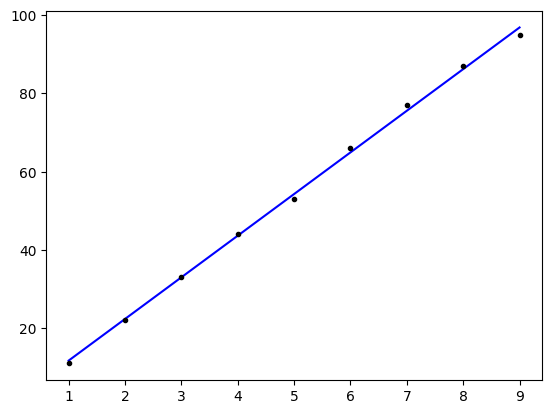

In [17]:
plt.plot(x, model.predict(x), 'b', x, y, 'k.')